# Income Classification with Naïve Bayes


## 1. Supervised model training


In [39]:
import pandas as pd
import numpy as np  
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.preprocessing import OrdinalEncoder

# Loading the supervised training dataset  
supervised_set = pd.read_csv('adult_supervised_train.csv')


all_features = ['age', 'workclass', 'education', 'education-num', 'marital-status', 
            'occupation', 'relationship', 'race', 'sex', 'capital-gain', 
            'capital-loss', 'hours-per-week', 'native-country']

target = 'income'

# Removing rows with missing values 
supervised_clean = supervised_set.dropna(subset=all_features)

# Splitting the dataset into features (X) and target (Y)
X = supervised_clean[all_features]
Y = supervised_clean[target]

# Separating continuous and categorical features 
continuous_features = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 
                        'relationship', 'race', 'sex', 'native-country']

continuous_X = X[continuous_features]
categorical_X = X[categorical_features]

# Training Gaussian Naive Bayes for continuous features
gNB_q1 = GaussianNB().fit(continuous_X, Y)


# Encoding categorical features 
# Unknown categories encountered during testing will be mapped to -1
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

encoder.fit(categorical_X)

categorical_X_enc = encoder.transform(categorical_X)

# Training Categorical Naive Bayes for categorical features (using Laplace smoothing applied by default)
cNB_q1 = CategoricalNB().fit(categorical_X_enc, Y)  

# Defining class indices for consistency
class_labels = gNB_q1.classes_

class_index = {c: i for i, c in enumerate(class_labels)}
low_inc_index = class_index['<=50K']
high_inc_index = class_index['>50K']

# Getting the prior probabilities 
priors = gNB_q1.class_prior_
prior_df = pd.DataFrame({"Class": class_labels, "Prior Probability": priors})
print(prior_df.round(3))

# Getting the means and standard deviations for each continuous feature 
continuous_means = gNB_q1.theta_
continuous_sd = np.sqrt(gNB_q1.var_)

mean_table = pd.DataFrame({"Feature": continuous_features, "Low Income Mean": continuous_means[low_inc_index], "High Income Mean": continuous_means[high_inc_index]})

sd_table = pd.DataFrame({"Feature": continuous_features, "Low Income SD": continuous_sd[low_inc_index], "High Income SD": continuous_sd[high_inc_index]})


print("\nContinuous Feature Means:")
print(mean_table.round(2))

print("\nContinuous Feature Standard Deviations:")
print(sd_table.round(2))

# Measuring how strongly each continuous feature separates the two classes using Cohen's d
cohen_q1 = []    

n_low_inc = np.sum(Y == '<=50K')
n_high_inc = np.sum(Y == '>50K')

# Reference for Cohen's d formula used - https://resources.nu.edu/statsresources/cohensd 
for fea_i, feature in enumerate(continuous_features):    

    mean_low_inc = continuous_means[low_inc_index, fea_i]
    mean_high_inc = continuous_means[high_inc_index, fea_i]

    var_low_inc = gNB_q1.var_[low_inc_index, fea_i]
    var_high_inc = gNB_q1.var_[high_inc_index, fea_i] 

    pooled_sd = np.sqrt(((n_low_inc - 1) * var_low_inc + (n_high_inc - 1) * var_high_inc) / (n_low_inc + n_high_inc - 2))

    d = abs(mean_high_inc - mean_low_inc) / pooled_sd

    cohen_q1.append( {"Feature": feature, "Cohen's d": d})

separation_q1 = pd.DataFrame(cohen_q1) 
separation_q1 = separation_q1.sort_values("Cohen's d", ascending=False)


print("\nSeparation:")
print(separation_q1.round(2))

# Measuring which category values are most strongly predictive of each class in this model using probability ratios 
Prob_ratio_calc = []

for fea_i, feature in enumerate(categorical_features):
    categories = encoder.categories_[fea_i]

    for cat_i, category in enumerate(categories):

        log_R = (cNB_q1.feature_log_prob_[fea_i][high_inc_index][cat_i] - cNB_q1.feature_log_prob_[fea_i][low_inc_index][cat_i])

        Prob_ratio_calc.append({"Feature": feature, "Category": category, "R": np.exp(log_R)})

prob_ratio_q1 = pd.DataFrame(Prob_ratio_calc)
prob_ratio_q1 = prob_ratio_q1.sort_values("R", ascending=False) 


# Finding the category value most predictive of each class for each feature 
Most_Predictive = []

for feature in categorical_features:

    single_feature = prob_ratio_q1[prob_ratio_q1["Feature"] == feature]

    high_inc_best = single_feature.loc[single_feature["R"].idxmax()]
    
    low_inc_best = single_feature.loc[single_feature["R"].idxmin()]

    Most_Predictive.append({"Feature": feature, "Class": ">50K", "Category": high_inc_best["Category"], "R": high_inc_best["R"]})

    Most_Predictive.append({"Feature": feature, "Class": "<=50K", "Category": low_inc_best["Category"], "R": low_inc_best["R"]})

Most_Predictive_Category_Values = pd.DataFrame(Most_Predictive)
print("\nMost Predictive Category Value Per Feature:")
print(Most_Predictive_Category_Values.round(2))

# Finding the 5 most predictive cateogory values for each class  
print("\n5 Most Predictive Category Values for High Income Class:")
high_inc_5 = prob_ratio_q1.sort_values("R", ascending=False).head(5)
print(high_inc_5[["Feature", "Category", "R"]].round(2))

print("\n5 Most Predictive Category Values for Low Income Class:")
low_inc_5 = prob_ratio_q1.sort_values("R", ascending=True).head(5)
print(low_inc_5[["Feature", "Category", "R"]].round(2))


   Class  Prior Probability
0  <=50K              0.754
1   >50K              0.246

Continuous Feature Means:
          Feature  Low Income Mean  High Income Mean
0             age            37.05             43.94
1   education-num             9.63             11.59
2    capital-gain           157.67           3607.15
3    capital-loss            55.97            202.36
4  hours-per-week            39.43             45.64

Continuous Feature Standard Deviations:
          Feature  Low Income SD  High Income SD
0             age          13.71           10.30
1   education-num           2.45            2.36
2    capital-gain        1017.86        13616.62
3    capital-loss         316.02          603.99
4  hours-per-week          11.91           10.40

Separation:
          Feature  Cohen's d
1   education-num       0.81
4  hours-per-week       0.54
0             age       0.53
2    capital-gain       0.51
3    capital-loss       0.36

Most Predictive Category Value Per Feature:
    

## 2. Supervised model evaluation


Test instances with at least one unseen category value: 1

ACCURACY: 0.811


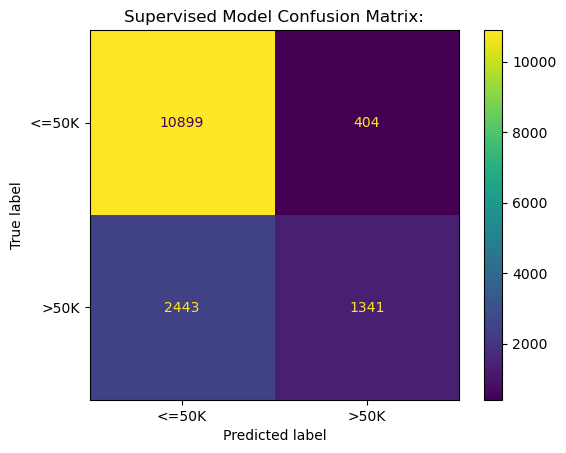


Supervised Model Classification Report:
              precision    recall  f1-score   support

       <=50K       0.82      0.96      0.88     11303
        >50K       0.77      0.35      0.49      3784

    accuracy                           0.81     15087
   macro avg       0.79      0.66      0.68     15087
weighted avg       0.80      0.81      0.78     15087


Mean Post Ratio:
   Class        Mean_R
0  <=50K  3.180000e-02
1  >=50K  4.579039e+42

Confident Instances for High Income Class:
      age  education-num  capital-gain  capital-loss  hours-per-week  \
8230   50             15         99999             0              50   
7187   42             14         99999             0              80   
7820   52             11         15024             0              40   

             workclass    education      marital-status       occupation  \
8230  Self-emp-not-inc  Prof-school  Married-civ-spouse  Exec-managerial   
7187  Self-emp-not-inc      Masters  Married-civ-spouse     

In [40]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

# Loading the test dataset  
test_set = pd.read_csv('adult_test.csv')

# Removing rows with missing values 
test_clean = test_set.dropna(subset=all_features)

# Splitting the test dataset into features (X) and target (Y)
X_test = test_clean[all_features]
Y_test = test_clean[target]

 
continuous_X_test = X_test[continuous_features]
categorical_X_test = X_test[categorical_features]

# Encoding the categorical features using the trained encoder from Q1
categorical_X_test_enc = encoder.transform(categorical_X_test)

# Counting instances with unknown category values
row_has_unknown = np.any(categorical_X_test_enc == -1, axis=1)
num_inst_with_unknown = np.sum(row_has_unknown)

print(f"\nTest instances with at least one unseen category value: {num_inst_with_unknown}")

# replacing -1 as the first category value for that feature to prevent invalid indexing 
categorical_X_test_enc[categorical_X_test_enc == -1] = 0

# Calculating log-probabilities 
log_prob_continuous = gNB_q1.predict_log_proba(continuous_X_test)
log_prob_categorical = cNB_q1.predict_log_proba(categorical_X_test_enc)
log_prior = np.log(gNB_q1.class_prior_)
log_prob_q1 = log_prior + log_prob_continuous + log_prob_categorical

# Making predictions from the log-probabilities 
y_pred_q1 = np.argmax(log_prob_q1, axis=1)
y_pred_q1 = class_labels[y_pred_q1]

# Getting the model accuracy, confusion matrix, and classification report
print("\nACCURACY:", round(accuracy_score(Y_test, y_pred_q1),3))

confusion_mat = confusion_matrix(Y_test, y_pred_q1, labels=['<=50K', '>50K'])
confusion_mat_disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mat, display_labels=['<=50K', '>50K'])
confusion_mat_disp.plot()
plt.title("Supervised Model Confusion Matrix:")
plt.show()

print("\nSupervised Model Classification Report:")
print(classification_report(Y_test, y_pred_q1))

# Calculating posterior ratios  
log_div = log_prob_q1[:, high_inc_index] - log_prob_q1[:, low_inc_index]

# Clipping the log ratios to prevent extreme values when exponentiating 
post_ratio_q1 = np.exp(np.clip(log_div, -100, 100))

test_pred = X_test.copy()
test_pred["pred"] = y_pred_q1
test_pred["R"] = post_ratio_q1
test_pred["distance from 1"] = np.abs(post_ratio_q1 - 1)


post_ratio_high_inc = test_pred[test_pred["pred"] == ">50K"]["R"]
post_ratio_low_inc = test_pred[test_pred["pred"] == "<=50K"]["R"]

# Calculating the mean posterior ratio for each class 
mean_post_ratio_table = pd.DataFrame({"Class": ["<=50K", ">=50K"], "Mean_R": [post_ratio_low_inc.mean(), post_ratio_high_inc.mean()]})

print("\nMean Post Ratio:")
print(mean_post_ratio_table.round(4))

# Getting the 3 most confident predictions for each class and instances closest to the decision boundary (lowest distance from 1)
high_inc_conf_inst = test_pred[test_pred["pred"] == ">50K"].sort_values("R", ascending=False).head(3)
low_inc_conf_inst = test_pred[test_pred["pred"] == "<=50K"].sort_values("R").head(3)
boundary_inst = test_pred.sort_values("distance from 1", ascending=True).head(3)

print("\nConfident Instances for High Income Class:")
print(high_inc_conf_inst[continuous_features + categorical_features + ["R"]])

print("\nConfident Instances for Low Income Class:")
print(low_inc_conf_inst[continuous_features + categorical_features + ["R"]])

print("\nNear Decision Boundary Instances:")
print(boundary_inst[continuous_features + categorical_features + ["R"]])

# Checking if any test instances were skipped 
print("\nTest instances:", len(X_test))
print("Predictions instances:", len(y_pred_q1))

## 3. Extending the model with semi-supervised training

In [41]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split


# Splitting the data into training and validation sets with stratification to maintain class balance
X_train, X_validate, Y_train, Y_validate = train_test_split(X, Y, test_size=0.2, random_state=10, stratify=Y)

continuous_X_train = X_train[continuous_features]
categorical_X_train = X_train[categorical_features]

# Training the model using the training split
gNB = GaussianNB().fit(continuous_X_train, Y_train)
categorical_X_train_enc = encoder.transform(categorical_X_train)
cNB = CategoricalNB().fit(categorical_X_train_enc, Y_train)


def pred_log_prob(gNB, cNB, encoder, X_set):
    
    """ This function calculates the total log-probabilities for each class by adding the GaussianNB log-probabilities (continuous features), 
    CategoricalNB log-probabilities (categorical features) and the log prior probabilities """
    
    X_cont = X_set[continuous_features]
    X_cat = X_set[categorical_features]
    X_cat_enc = encoder.transform(X_cat)
    X_cat_enc[X_cat_enc == -1] = 0

    log_cont = gNB.predict_log_proba(X_cont)
    log_cat = cNB.predict_log_proba(X_cat_enc)
    log_pri = np.log(gNB.class_prior_)

    return log_pri + log_cont + log_cat

# Loading the unlabelled dataset 
unlabelled_set = pd.read_csv("adult_unlabelled.csv")

# Removing rows with missing values 
unlabelled_clean = unlabelled_set.dropna(subset=all_features)
X_unlabelled = unlabelled_clean[all_features]

# calculating log-probabilities for the unlabelled dataset 
log_prob_unlabelled = pred_log_prob(gNB, cNB, encoder, X_unlabelled)

# Assigning pseudo-labels 
y_pseudo = np.argmax(log_prob_unlabelled, axis=1)
y_pseudo = class_labels[y_pseudo]


def train_and_validate(mod_X, mod_Y):
    """ This function trains the mixed Naive Bayes model on the given features and labels, 
    then evaluates its performance on the validation set """

    mod_X_cat = mod_X[categorical_features]
    mod_X_cont = mod_X[continuous_features]
    
    g = GaussianNB().fit(mod_X_cont, mod_Y)

    X_cat = encoder.transform(mod_X_cat)
    c = CategoricalNB().fit(X_cat, mod_Y)

    log_val = pred_log_prob(g, c, encoder, X_validate)
    pred = np.argmax(log_val, axis=1)
    pred = class_labels[pred]

    return accuracy_score(Y_validate, pred)


# Fitting Model A using the training split and all pseudo labels 

mod_A_X = pd.concat([X_train, X_unlabelled])
mod_A_Y = pd.concat([Y_train, pd.Series(y_pseudo, index=X_unlabelled.index)])
accuracy_A = train_and_validate(mod_A_X, mod_A_Y)

print("\nModel A Result:")
print(f"Accuracy: {accuracy_A:.3f}")

# Fitting Model B using the training split and only high-confidence pseudo labels 

# Calculating the log posterior ratios  
log_div_unlabelled = (log_prob_unlabelled[:, high_inc_index] - log_prob_unlabelled[:, low_inc_index]) 

# Taking the absolute value to measure their distance from the decision boundary 
confidence = np.abs(log_div_unlabelled)


percentiles = [10, 15, 20, 25, 30, 35]  # Chosen hyperparameter percentile values for confidence-based filtering

Model_B_validation = [] 

for p in percentiles:

    threshold = np.percentile(confidence, p)

    confidence_filter = confidence >= threshold

    # Selecting the high-confidence pseudo-labels
    selected_X = X_unlabelled[confidence_filter]
    selected_Y = y_pseudo[confidence_filter]

    unlabelled_kept = (len(selected_X) / len(X_unlabelled)) * 100

    # Retraining the model using the filtered pseudo-labels
    mod_B_X = pd.concat([X_train, selected_X])
    mod_B_Y = pd.concat([Y_train, pd.Series(selected_Y, index=selected_X.index)])

    # Evaluating performance on the validation set 
    accuracy_B = train_and_validate(mod_B_X, mod_B_Y)
    Model_B_validation.append({ "Percentile": p, "Unlabelled Data Kept (%)": unlabelled_kept, "Validation Accuracy": accuracy_B})

Model_B_results = pd.DataFrame(Model_B_validation)

best_accuracy_B = Model_B_results.loc[Model_B_results["Validation Accuracy"].idxmax()]

print("\nModel B Hyperparameter Tuning:")
print(Model_B_results.round(4))

print("\nBest Model B Result:")
print(best_accuracy_B.round(3))
 

# Fitting Model C through iterative label propagation
splits = [0.3, 0.4, 0.5, 0.6]  # Chosen splits to use on the unlabelled data during hyperparameter tuning 

Model_C_validation = []

for s in splits:

    # Shuffling the unlabelled data before hyperparameter tuning
    
    # Using a fixed random seed to ensure validation performance remains comparable across iterations
    X_un_shuffle = X_unlabelled.sample(frac=1, random_state=42)   

    index_of_split = int(s * len(X_un_shuffle))

    X_1 = X_un_shuffle.iloc[:index_of_split]
    X_2 = X_un_shuffle.iloc[index_of_split:]

    # Labelling first subset 
    log_prob_1 = pred_log_prob(gNB, cNB, encoder, X_1)

    y_pred_1 = np.argmax(log_prob_1, axis=1)
    y_pred_1 = class_labels[y_pred_1] 

    mod_C_X1 = pd.concat([X_train, X_1])
    mod_C_Y1 = pd.concat([Y_train, pd.Series(y_pred_1, index=X_1.index)])

    g2 = GaussianNB().fit(mod_C_X1[continuous_features], mod_C_Y1)
    X_cat_1 = encoder.transform(mod_C_X1[categorical_features])
    c2 = CategoricalNB().fit(X_cat_1, mod_C_Y1)

    # Labelling the second subset 
    log_prob_2 = pred_log_prob(g2, c2, encoder, X_2)

    y_pred_2 = np.argmax(log_prob_2, axis=1)
    y_pred_2 = class_labels[y_pred_2]

    mod_C_X = pd.concat([mod_C_X1, X_2])
    mod_C_Y = pd.concat([mod_C_Y1, pd.Series(y_pred_2, index=X_2.index)])

    # Evaluating performance on the validation set 
    accuracy_C = train_and_validate(mod_C_X, mod_C_Y)

    Model_C_validation.append({"Split (%)": int(s * 100),  "Validation Accuracy": accuracy_C})
    

Model_C_results = pd.DataFrame(Model_C_validation)

best_accuracy_C = Model_C_results.loc[Model_C_results["Validation Accuracy"].idxmax()]

print("\nModel C Hyperparameter Tuning:")
print(Model_C_results.round(4))

print("\nBest Model C Result:")
print(best_accuracy_C.round(3))


# Retraining the best performing semi-supervised model (Model B) on the full supervised training dataset  

# Combining the training and validation sets 
supervised_X = pd.concat([X_train, X_validate])
supervised_Y = pd.concat([Y_train, Y_validate])

supervised_X_categorical = supervised_X[categorical_features]
supervised_X_continuous = supervised_X[continuous_features]


gNB_full = GaussianNB().fit(supervised_X_continuous, supervised_Y)
supervised_X_categorical_enc = encoder.transform(supervised_X_categorical)
supervised_X_categorical_enc[supervised_X_categorical_enc == -1] = 0
cNB_full = CategoricalNB().fit(supervised_X_categorical_enc, supervised_Y)


log_prob_unlabelled = pred_log_prob(gNB_full, cNB_full, encoder, X_unlabelled)

# Assigning pseudo-labels 
y_pseudo_fin_index = np.argmax(log_prob_unlabelled, axis=1)
y_pseudo_fin = class_labels[y_pseudo_fin_index]

log_div = (log_prob_unlabelled[:, high_inc_index] - log_prob_unlabelled[:, low_inc_index])
confidence = np.abs(log_div)

# Keeping the top 70% most confident pseudo-labels
threshold = np.percentile(confidence, 30)
confidence_filter = confidence >= threshold

selected_X = X_unlabelled[confidence_filter]
selected_Y = y_pseudo_fin[confidence_filter]

# Combining supervised training data (training + validation) with high-confidence pseudo-labelled data
X_final = pd.concat([supervised_X, selected_X])
Y_final = pd.concat([supervised_Y, pd.Series(selected_Y, index=selected_X.index)])

X_final_categorical = X_final[categorical_features]
X_final_continuous = X_final[continuous_features] 

# Final model training on the combined data
gNB_q3 = GaussianNB().fit(X_final_continuous, Y_final)
X_final_categorical_enc = encoder.transform(X_final_categorical)
X_final_categorical_enc[X_final_categorical_enc == -1] = 0

cNB_q3 = CategoricalNB().fit(X_final_categorical_enc, Y_final)


Model A Result:
Accuracy: 0.786

Model B Hyperparameter Tuning:
   Percentile  Unlabelled Data Kept (%)  Validation Accuracy
0          10                   89.9993               0.7875
1          15                   84.9990               0.7885
2          20                   79.9987               0.7888
3          25                   74.9983               0.7888
4          30                   69.9980               0.7895
5          35                   64.9977               0.7921

Best Model B Result:
Percentile                  35.000
Unlabelled Data Kept (%)    64.998
Validation Accuracy          0.792
Name: 5, dtype: float64

Model C Hyperparameter Tuning:
   Split (%)  Validation Accuracy
0         30               0.7855
1         40               0.7855
2         50               0.7855
3         60               0.7855

Best Model C Result:
Split (%)              30.000
Validation Accuracy     0.785
Name: 0, dtype: float64


## 4. Supervised model evaluation

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew

test_set = pd.read_csv('adult_test.csv')
test_clean = test_set.dropna(subset=all_features)

X_test = test_clean[all_features]
Y_test = test_clean[target]


# Calculatng the log-probabilities for the final semi-supervised model 
log_prob_q3 = pred_log_prob(gNB_q3, cNB_q3, encoder, X_test)

# Making predictions from the log-probabilities 
y_pred_q3 = np.argmax(log_prob_q3, axis=1)
y_pred_q3 = class_labels[y_pred_q3]


def model_perform_metrics(y_true, y_pred, name):
    """ This function calculates the accuracy, precision, recall and F1 scores 
    for a given model using the true and predicted labels """
    return {"Model": name, "Accuracy": accuracy_score(y_true, y_pred), "Precision": precision_score(y_true, y_pred, pos_label='>50K'),
        "Recall": recall_score(y_true, y_pred, pos_label='>50K'), "F1": f1_score(y_true, y_pred, pos_label='>50K')}

# Storing the performance metrics for both supervised and semi-supervised models 
metrics = pd.DataFrame([model_perform_metrics(Y_test, y_pred_q1, "Supervised Model"), model_perform_metrics(Y_test, y_pred_q3, "Semi-Supervised Model")])

print("\nModel Performance Metrics Comparison:")
print(metrics.round(4))


# Calculating the posterior ratios for the semi-supervised model 
log_div_q3 = log_prob_q3[:, high_inc_index] - log_prob_q3[:, low_inc_index]

# Clipping the log ratios to prevent extreme values when exponentiating 
post_ratio_q3 = np.exp(np.clip(log_div_q3, -100, 100))

def post_ratio_distribution(R, name):
    """ This function calculates the mean, median, IQR, standard deviation and skewness for the posterior ratio distribution """

    Q1 = np.percentile(R, 25)
    Q3 = np.percentile(R, 75)

    return pd.DataFrame([{"Name": name, "Mean": np.mean(R), "Median": np.median(R), "Standard Deviation": np.std(R), "IQR": Q3 - Q1, "Skewness": skew(R)}])
    

# Computing the distribution statistics for both models 
R_q1_distribution = post_ratio_distribution(post_ratio_q1, "Supervised Model")
R_q3_distribution = post_ratio_distribution(post_ratio_q3, "Semi-Supervised Model")

combined_distribution = pd.concat([R_q1_distribution, R_q3_distribution],ignore_index=True)

print("\nPosterior Ratio Distribution Statistics Comparison:")
print(combined_distribution.round(5))

# Tracking how the continuous feature parameters change across the supervised and semi-supervised models  
mean_record = []
var_record = []

for fea_i, feature in enumerate(continuous_features):
    for class_index, class_name in enumerate(class_labels):
        
        # calculating the difference in the mean and variance of each continuous feature for each class  
        mean_diff = gNB_q3.theta_[class_index, fea_i] - gNB_q1.theta_[class_index, fea_i]
        var_diff = gNB_q3.var_[class_index, fea_i] - gNB_q1.var_[class_index, fea_i]

        mean_record.append({"Feature": feature, "Class": class_name, "Mean Shift": mean_diff, "Inc/Dec": "Increase" if mean_diff > 0 else "Decrease"})

        var_record.append({"Feature": feature, "Class": class_name, "Variance Change": var_diff, "Inc/Dec": "Increase" if var_diff > 0 else "Decrease"})

mean_change = pd.DataFrame(mean_record)
var_change = pd.DataFrame(var_record)

print("\nChange in Means")
print(mean_change.round(4))

print("\nChange in Variance")
print(var_change.round(4))

# Tracking how the categorical feature parameters change across the supervised and semi-supervised models  
categorical_record = []

for fea_i, feature in enumerate(categorical_features):

    q1 = cNB_q1.feature_log_prob_[fea_i]
    q3 = cNB_q3.feature_log_prob_[fea_i]

    for class_idx, class_name in enumerate(class_labels):

        # calculating the difference in the log-probabilities of each categorical feature for each class    
        diff = q3[class_idx] - q1[class_idx]

        categorical_record.append({"Feature": feature, "Class": class_name, "LogProb Change": np.mean(diff), "Direction": "Increase" if np.mean(diff) > 0 else "Decrease"})

categorical_change = pd.DataFrame(categorical_record)

print("\nChange in Category Probabilities")
print(categorical_change.round(4))

# Measuring which category values are most strongly predictive of each class in the semi-supervised model using probability ratios 
prob_ratio_calc_q3 = []

for fea_i, feature in enumerate(categorical_features):
    categories = encoder.categories_[fea_i]

    for cat_i, category in enumerate(categories):

        log_R = (cNB_q3.feature_log_prob_[fea_i][high_inc_index][cat_i] - cNB_q3.feature_log_prob_[fea_i][low_inc_index][cat_i])

        prob_ratio_calc_q3.append({"Feature": feature, "Category": category, "R": np.exp(log_R)})

prob_ratio_q3 = pd.DataFrame(prob_ratio_calc_q3)
prob_ratio_q3 = prob_ratio_q3.sort_values("R", ascending=False)
prob_ratio_q3["R"] = prob_ratio_q3["R"].round(2)
prob_ratio_q1["R"] = prob_ratio_q1["R"].round(2)

# Extracting the top 5 predictors for each class and model 
prob_ratio_q3_high_inc = prob_ratio_q3.head(5)
prob_ratio_q3_low_inc = prob_ratio_q3.tail(5)
prob_ratio_q1_high_inc = prob_ratio_q1.head(5)
prob_ratio_q1_low_inc = prob_ratio_q1.tail(5)

# Comparing the top predictors between the two models 
print("\nSupervised Model Top 5 Predictors For High Income Class:")
print(prob_ratio_q1_high_inc)

print("\nSemi-Supervised Model Top 5 Predictors For High Income Class:")
print(prob_ratio_q3_high_inc)

print("\nSupervised Model Top 5 Predictors For Low Income Class:")
print(prob_ratio_q1_low_inc)

print("\nSemi-Supervised Model Top 5 Predictors For Low Income Class:")
print(prob_ratio_q3_low_inc)

# Measuring how strongly each continuous feature separates the two classes in the semi-supervised model using Cohen's d
cohen_q3 = []

n_low_inc_q3 = np.sum(Y_final == '<=50K')
n_high_inc_q3 = np.sum(Y_final == '>50K')

for fea_i, feature in enumerate(continuous_features):    

    mean_low_inc = gNB_q3.theta_[low_inc_index, fea_i]
    mean_high_inc = gNB_q3.theta_[high_inc_index, fea_i]

    var_low_inc = gNB_q3.var_[low_inc_index, fea_i]
    var_high_inc = gNB_q3.var_[high_inc_index, fea_i]

    pooled_sd = np.sqrt(((n_low_inc_q3 - 1) * var_low_inc + (n_high_inc_q3 - 1) * var_high_inc) / (n_low_inc_q3 + n_high_inc_q3 - 2))

    d = abs(mean_high_inc - mean_low_inc) / pooled_sd

    cohen_q3.append({"Feature": feature, "Cohen's d": d})

separation_q3 = pd.DataFrame(cohen_q3)
separation_q3 = separation_q3.sort_values("Cohen's d", ascending=False)

# Comparing the separation between the two models 
print("\nSupervised Model Separation:")
print(separation_q1.round(2))

print("\nSemi-Supervised Model Separation:")
print(separation_q3.round(2))


Model Performance Metrics Comparison:
                   Model  Accuracy  Precision  Recall      F1
0       Supervised Model    0.8113     0.7685  0.3544  0.4851
1  Semi-Supervised Model    0.7981     0.7055  0.3348  0.4541

Posterior Ratio Distribution Statistics Comparison:
                    Name          Mean   Median  Standard Deviation      IQR  \
0       Supervised Model  5.296231e+41  0.00040        3.731904e+42  0.01874   
1  Semi-Supervised Model  6.147077e+41  0.00006        4.018213e+42  0.00476   

   Skewness  
0   6.91234  
1   6.38387  

Change in Means
          Feature  Class  Mean Shift   Inc/Dec
0             age  <=50K     -0.7731  Decrease
1             age   >50K      0.2413  Increase
2   education-num  <=50K     -0.1237  Decrease
3   education-num   >50K      0.1094  Increase
4    capital-gain  <=50K    -55.3556  Decrease
5    capital-gain   >50K   2457.3063  Increase
6    capital-loss  <=50K    -23.5951  Decrease
7    capital-loss   >50K    124.7155  Increase